# 🦅 A Qiskit on IBM Heron Tutorial

This is just a basic tutorial walkthrough summed up in 1 notebook.

The original source and steps are found starting at [IBM](https://quantum.cloud.ibm.com/learning/en/courses/use-a-qc-today).

## Setup & Imports

Qiskit with Aer simulator and real QPU execution for testing.

In [5]:
# Core Qiskit imports
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# IBM Runtime specific imports
from qiskit_ibm_runtime import SamplerV2 as Sampler, QiskitRuntimeService
import qiskit
import qiskit_aer
import qiskit_ibm_runtime

# System
import os
import sys
from dotenv import load_dotenv

print("Python:", sys.version.split()[0])
print("qiskit:", qiskit.__version__)
print("qiskit-aer:", qiskit_aer.__version__)
print("qiskit-ibm-runtime:", qiskit_ibm_runtime.__version__)

Python: 3.12.13
qiskit: 2.4.1
qiskit-aer: 0.17.2
qiskit-ibm-runtime: 0.47.0


## Bell State

To test the IBM runtime, we will create a simple Bell state circuit and run it on the backend to verify that we get the expected results. The Bell state (specifically the phi-plus state) is a maximally entangled state of two qubits - either both measured bits are 00, or 11.

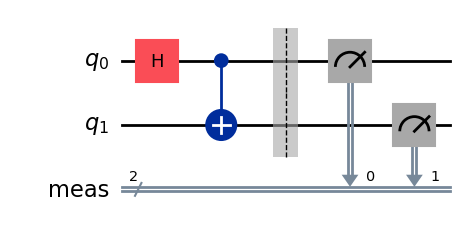

In [6]:
# --- Build the Bell circuit (phi-plus) ---
bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)
bell.measure_all()  # creates a classical register named "meas"

bell.draw("mpl")

## Prepare to Run

Following function is designed to execute arbitrary circuits in the given backend(s).

In [7]:
def run_circuit_and_get_counts(circuit, backend, shots=100):
    """
    Runs a quantum circuit on a specified backend and returns the measurement counts.

    Args:
        circuit (QuantumCircuit): The quantum circuit to run.
        backend: The Qiskit backend (real device or simulator).
        shots (int): The number of shots to run the circuit.

    Returns:
        dict: A dictionary of measurement counts.
    """
    pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
    isa_circuit = pm.run(circuit)

    sampler = Sampler(mode=backend)

    job = sampler.run([isa_circuit], shots=shots)
    result = job.result()

    return result[0].data.meas.get_counts()

## Run

Before running, provide your credentials in the `.env` file (see `.env.example`).

Then, specify which backend to use by commenting out or overwriting the backend variable.  The least busy backend is a good choice for real device execution, but you can also specify a particular backend by name.

qiskit_runtime_service.__init__:WARNING:2026-05-30 21:40:51,346: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.__init__:WARNING:2026-05-30 21:40:53,290: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:20

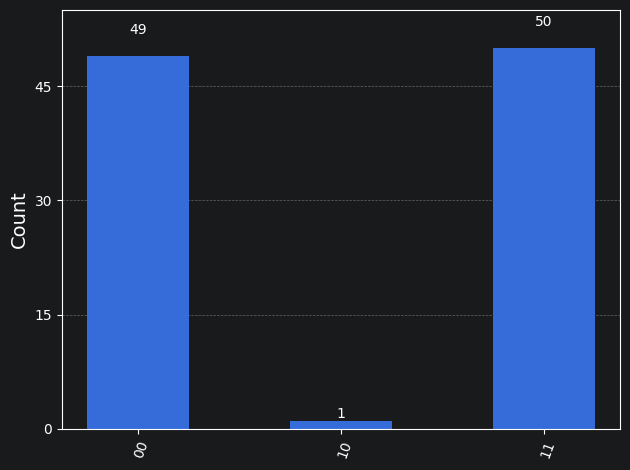

In [8]:
load_dotenv()
IBM_KEY = os.getenv('IBM_KEY')

# Syntax for first saving your token.  Delete these lines after saving your credentials.
QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token=IBM_KEY,
    overwrite=True,
    set_as_default=True,
)

service = QiskitRuntimeService(channel="ibm_quantum_platform")

# Load saved credentials
service = QiskitRuntimeService()

# Use the least busy backend, or uncomment the loading of a specific backend like "ibm_fez".
backend = service.least_busy(operational=True, simulator=False, min_num_qubits=127)
# backend = service.backend("ibm_fez")
# backend = AerSimulator()

counts = run_circuit_and_get_counts(bell, backend, shots=100)

plot_histogram(counts)